# 실습 6-2 : STUCCO (대조집합 학습)

#### **<실습 내용>**

1. 대조집합 학습 개요
- STUCCO 알고리즘 원리

2. STUCCO 기본 예제 (Process_Data)
- 데이터 전처리 (연속형 변수 범주화)
- 대조집합(cset) 도출 및 해석

3. Vibe Coding 실습 (통신사 고객 이탈 데이터)

## 분석 준비

### 주요 라이브러리 호출

In [25]:
#한글폰트
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "AppleGothic"   # macOS 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False     # 마이너스 기호 깨짐 방지

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import logging
from stucco import ContrastSetLearner  # 대조집합 학습(Contrast Set Learning)을 수행하는 STUCCO 알고리즘 구현체

logging.getLogger().setLevel(logging.WARNING)  # stucco.py의 상세 진행 로그 숨기기

---

## 1) 데이터 불러오기

In [3]:
data = pd.read_csv("dataset/day6-2_data.csv")
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (596, 12)


,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0


In [4]:
# 불량 기준 설정: 제품 1개당 불량 개수(Y)가 3개 이상이면 Fault, 아니면 Pass로 그룹 라벨 생성
data["Fail"] = ["Fault" if i >= 3 else "Pass" for i in data["Y"]]
data

,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y,Fail
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0,Pass
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0,Pass
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4,Fault
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0,Pass
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,1001592,15,E,A,C,D,115.153,31.652,A,A,C,0,Pass
592,1001593,15,E,A,B,D,114.593,33.890,A,A,B,0,Pass
593,1001594,20,U,A,A,B,105.724,33.251,B,B,A,0,Pass
594,1001595,25,E,A,A,A,109.783,32.054,A,A,D,0,Pass


In [5]:
print("클래스 분포:")
print(data["Fail"].value_counts())

클래스 분포:
Fail
Pass     471
Fault    125
Name: count, dtype: int64


**활용할 반도체 공정 데이터 소개 (6-1과 동일)**

| 변수 | 설명 |
|---|---|
| Prod_ID | 제품 고유 ID |
| M1 | 공정 설비 온도 설정값 (15/20/25/30) |
| M2 | 사용 설비 ID (E, U, K) |
| P1 ~ P6 | 제품 설계/공정 옵션 (범주형 파라미터) |
| C1, C2 | 공정 중 측정된 연속형 값 |
| Y | 제품 1개당 발생한 불량 개수 |
| Fail | Y >= 3이면 Fault, 아니면 Pass로 정의한 라벨 |

## 2) 전처리하기

> STUCCO는 입력변수로 **범주형 변수만** 허용하므로 연속형 변수(C1, C2)는 구간화하여 범주형 변수 처럼 나타내야함

In [6]:
# 1. M1
# 숫자(15/20/25/30)로 저장되어 있음
# 그러나 실제로는 '온도 설정값'을 의미하는 범주이므로 범주형으로 변환
data["M1"] = data["M1"].astype("object")

# 2. 연속형 변수 C1, C2
# qcut: 데이터 개수가 균등하도록 4구간으로 분할
data["C1_cut"] = pd.qcut(data["C1"], 4)
# cut: 의미 있는 경계값 기준으로 직접 3구간 지정
data["C2_cut"] = pd.cut(data["C2"], bins=[18, 28, 32, 39], labels=["Low", "Normal", "High"]) 

### 2-1) STUCCO 실행

1. 비교할 그룹 설정
2. Contrast Set 후보 규칙 생성
3. 유의미한 규칙 추출

In [7]:
# STUCCO에 불필요한 변수 제거
# (ID, 이미 구간화한 원본 연속형 변수, 라벨 만드는 데 쓴 Y)
contra_data = data.drop(["Prod_ID", "C1", "C2", "Y"], axis=1)
contra_data

,M1,M2,P1,P2,P3,P4,P5,P6,Fail,C1_cut,C2_cut
0,15,E,A,B,D,A,A,B,Pass,"(109.191, 112.225]",Low
1,20,E,A,B,D,A,A,A,Pass,"(109.191, 112.225]",Low
2,15,U,A,B,B,B,B,B,Fault,"(109.191, 112.225]",Low
3,25,K,B,B,C,A,A,C,Pass,"(106.365, 109.191]",Low
4,20,E,A,A,D,B,B,A,Pass,"(102.158, 106.365]",Normal
...,...,...,...,...,...,...,...,...,...,...,...
591,15,E,A,C,D,A,A,C,Pass,"(112.225, 123.34]",Normal
592,15,E,A,B,D,A,A,B,Pass,"(112.225, 123.34]",High
593,20,U,A,A,B,B,B,A,Pass,"(102.158, 106.365]",High
594,25,E,A,A,A,A,A,D,Pass,"(109.191, 112.225]",High


> 1. 비교할 그룹 설정 (ContrastSetLearner())

In [8]:
# ContrastSetLearner(DataFrame, group_feature)

# "Fail" 컬럼의 그룹을 기준으로 Contrast Set 탐색
# Contrast Set: 그룹 간 차이를 가장 잘 설명하는 규칙

learner = ContrastSetLearner(contra_data, group_feature="Fail")
learner

> 2. Contrast Set 후보 규칙 생성 (learn())

In [9]:
# learner.learn():
# 그룹 간 차이를 설명할 수 있는 규칙 후보(조건 조합)를 생성
# 각 규칙의 그룹별 등장 빈도를 계산

# max_length: 규칙을 구성하는 최대 조건 수
# n_matrices: 규칙이 각 그룹에서 몇 번 나타났는지 등의 빈도 정보를 저장

n_matrices = learner.learn(max_length=3)
n_matrices

4217

> 3. 유의미한 규칙 추출 (score())

In [10]:
# learner.score():
# learn( )에서 생성한 빈도 정보를 활용해 규칙별 Support, Confidence, Lift를 계산

# Support: 규칙의 출현 비율
# Confidence: 규칙이 나타났을 때 해당 그룹일 확률
# Lift: 특정 그룹과의 연관성 정도

# lift가 2.0 이상인(특정 그룹과의 연관성 정도) 규칙만 채택
contrast_rules = learner.score(min_lift=2.0)
contrast_rules

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fail=>Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fail=>Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fail=>Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fail=>Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fail=>Fault,2.300000
5,"(P1=>A, P6=>D, C1_cut=>(106.365, 109.191])",Fail=>Fault,2.258065
9,"(M2=>K, P1=>A, P2=>B)",Fail=>Fault,2.250000
10,"(P1=>A, P5=>B, C1_cut=>(112.225, 123.34])",Fail=>Fault,2.222222
8,"(P1=>A, P3=>D, P6=>D)",Fail=>Fault,2.181818
16,"(M1=>25, M2=>K, P1=>A)",Fail=>Fault,2.181818


In [11]:
# group 컬럼 값이 "Fail=>Fault", "Fail=>Pass" 형태로 저장되어 있음
# 보기 쉽게 "Fault", "Pass"만 남도록 문자열 변경
contrast_rules["group"] = contrast_rules["group"].str.replace("Fail=>", "")

# learn() 단계에서 생성된 전체 조건 조합(규칙 후보) 수 출력
print("생성된 조건 조합 수:", n_matrices)

# score() 단계의 기준을 통과하여 최종 선택된 Contrast Set 규칙 수 출력
print("도출된 규칙 수:", contrast_rules.shape[0])

생성된 조건 조합 수: 4217
도출된 규칙 수: 17


### 2-2) 결과 해석

In [12]:
# 도출된 규칙 확인
# 실제로는 Pass 규칙도 있었는데 score 기준에 따라 필터링 된 것임

contrast_rules.head()

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fault,2.300000


In [ ]:
# Fault 그룹을 설명하는 규칙만 추출
fault_rules = contrast_rules.loc[contrast_rules["group"] == "Fault"]

# Lift 기준 상위 5개 규칙 확인
fault_rules.sort_values(by="lift", ascending=False).head()

In [ ]:
# Lift가 가장 높은 Contrast Set 규칙
# (P1=A) AND (P3=A) AND (C2_cut=High)를 만족하는 데이터 선택

cset_mask = (data["P1"] == "A") & (data["P3"] == "A") & (data["C2_cut"] == "High")

# 규칙을 만족하는 데이터의 불량(Fail) 분포 확인
print("cset 해당 데이터 불량 분포:")
print(data.loc[cset_mask, "Fail"].value_counts())
print()

# 규칙을 만족하지 않는 데이터의 불량(Fail) 분포 확인
print("cset 미해당 데이터 불량 분포:")
print(data.loc[~cset_mask, "Fail"].value_counts())

---

## 3) Vibe Coding 실습 (통신사 고객 이탈 데이터)

STUCCO를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 직접 적용해 봅니다.

- `dataset/day6_vibecoding.csv` 파일 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

In [13]:
# 필요한 라이브러리 호출하기
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# 0. 데이터 불러오기
data = pd.read_csv('dataset/day6_vibecoding.csv')

# 1. 결측치 처리
# 범주형(InternetService, PaymentMethod) → 최빈값 대치
for col in ['InternetService', 'PaymentMethod']:
    data[col] = data[col].fillna(data[col].mode()[0])

# TotalCharges → 중앙값 대치
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# tenure, MonthlyCharges → KNN Imputer (비슷한 고객들의 값을 참고해 대치)
knn_cols = ['tenure', 'MonthlyCharges']
imputer = KNNImputer(n_neighbors=5)
data[knn_cols] = imputer.fit_transform(data[knn_cols])

# 2. 군집화에 쓰지 않을 컬럼 분리 
# Churn: 군집화 단계에서는 사용하지 않고, 군집 해석(군집별 이탈률 비교) 시에만 참고
churn = data['Churn']
X = data.drop(columns=['Churn'])

# 3. 수치형 변수 스케일링 
# K-Means/DBSCAN은 거리 기반이라 변수 스케일이 다르면 특정 변수가 거리 계산을 왜곡할 수 있음
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# 4. 범주형 변수 인코딩 
# 값이 2개뿐인 이진 범주형 변수는 0/1로 Label Encoding
binary_map = {
    'gender':           {'Male': 1, 'Female': 0},
    'Partner':          {'Yes': 1, 'No': 0},
    'Dependents':       {'Yes': 1, 'No': 0},
    'PhoneService':     {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map.items():
    X[col] = X[col].map(mapping)

# 값이 3개 이상인 다중 범주형 변수는 One-Hot Encoding
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
X = pd.get_dummies(X, columns=ohe_cols, drop_first=True)

X.head()

/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.286364,0,1,-1.177403,-0.994242,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.069230,1,0,-0.265705,-0.173244,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.245285,1,1,-0.369996,-0.959674,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.521095,0,0,-0.758560,-0.194766,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.245285,1,1,0.196872,-0.940470,False,...,False,False,False,False,False,False,False,False,True,False


**[과제]** 본 데이터셋에서의 연속형 범수인 'tenure', 'MonthlyCharges', 'TotalCharges'를 `pd.qcut` 등으로 구간화하고 `ContrastSetLearner`로 Churn(Yes/No) 그룹 간 대조집합을 도출하는 코드를 AI와 상의해서 작성하세요.

In [16]:
import logging
import pandas as pd
from sklearn.impute import KNNImputer
from stucco import ContrastSetLearner

logging.getLogger().setLevel(logging.WARNING)

# ── 0. 데이터 불러오기 & 결측치 처리 ──
data = pd.read_csv('dataset/day6_vibecoding.csv')

for col in ['InternetService', 'PaymentMethod']:
    data[col] = data[col].fillna(data[col].mode()[0])

data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

knn_cols = ['tenure', 'MonthlyCharges']
imputer = KNNImputer(n_neighbors=5)
data[knn_cols] = imputer.fit_transform(data[knn_cols])

print("Churn 분포:")
print(data['Churn'].value_counts())

Churn 분포:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [17]:
# ── 1. 연속형 변수 pd.qcut 구간화 ──
# STUCCO는 범주형만 허용 → tenure 등을 구간(범주)으로 변환
data['tenure_cut'] = pd.qcut(data['tenure'], q=4, duplicates='drop')
data['MonthlyCharges_cut'] = pd.qcut(data['MonthlyCharges'], q=4, duplicates='drop')
data['TotalCharges_cut'] = pd.qcut(data['TotalCharges'], q=4, duplicates='drop')

# 구간 확인
for col in ['tenure_cut', 'MonthlyCharges_cut', 'TotalCharges_cut']:
    print(f"\n[{col}]")
    print(data[col].value_counts().sort_index())


[tenure_cut]
tenure_cut
(-0.001, 9.0]    1826
(9.0, 29.0]      1729
(29.0, 55.0]     1776
(55.0, 72.0]     1712
Name: count, dtype: int64

[MonthlyCharges_cut]
MonthlyCharges_cut
(18.249, 39.125]    1761
(39.125, 70.2]      1765
(70.2, 89.55]       1761
(89.55, 118.75]     1756
Name: count, dtype: int64

[TotalCharges_cut]
TotalCharges_cut
(18.799, 402.225]      1761
(402.225, 1397.475]    1766
(1397.475, 3786.6]     1755
(3786.6, 8684.8]       1761
Name: count, dtype: int64


In [18]:
# ── 2. STUCCO 입력 데이터 준비 ──
# 원본 연속형 제거 (구간화 변수로 대체)
contra_data = data.drop(columns=['tenure', 'MonthlyCharges', 'TotalCharges'])

# SeniorCitizen: 0/1 → 문자열 (숫자 편향으로 STUCCO가 제거하는 것 방지)
contra_data['SeniorCitizen'] = contra_data['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

contra_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,tenure_cut,MonthlyCharges_cut,TotalCharges_cut
0,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No,"(-0.001, 9.0]","(18.249, 39.125]","(18.799, 402.225]"
1,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No,"(29.0, 55.0]","(39.125, 70.2]","(1397.475, 3786.6]"
2,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,"(-0.001, 9.0]","(39.125, 70.2]","(18.799, 402.225]"
3,Male,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No,"(29.0, 55.0]","(39.125, 70.2]","(1397.475, 3786.6]"
4,Female,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes,"(-0.001, 9.0]","(70.2, 89.55]","(18.799, 402.225]"


In [19]:
# ── 3. ContrastSetLearner: Churn(Yes/No) 그룹 간 대조집합 학습 ──
learner = ContrastSetLearner(contra_data, group_feature='Churn')
learner

In [20]:
# ── 4. 후보 규칙 생성 ──
n_matrices = learner.learn(max_length=3)
print("생성된 조건 조합 수:", n_matrices)

생성된 조건 조합 수: 20096


In [21]:
# ── 5. 유의미한 대조집합(Contrast Set) 추출 ──
contrast_rules = learner.score(min_lift=2.0)

# "Churn=>Yes" → "Yes" 로 정리
contrast_rules['group'] = contrast_rules['group'].str.replace('Churn=>', '')

print("도출된 규칙 수:", contrast_rules.shape[0])
contrast_rules.head(10)

도출된 규칙 수: 326


,rule,group,lift
258,"(InternetService=>Fiber optic, PaymentMethod=>...",Yes,4.626094
142,"(StreamingMovies=>Yes, Contract=>Month-to-mont...",Yes,4.575754
295,"(MultipleLines=>Yes, InternetService=>Fiber op...",Yes,4.545544
122,"(StreamingTV=>Yes, Contract=>Month-to-month, t...",Yes,4.470496
309,"(SeniorCitizen=>Yes, StreamingMovies=>Yes, Con...",Yes,4.329400
272,"(DeviceProtection=>No, Contract=>Month-to-mont...",Yes,4.165140
248,"(PaperlessBilling=>Yes, MonthlyCharges_cut=>(7...",Yes,4.052346
271,"(OnlineBackup=>No, Contract=>Month-to-month, M...",Yes,4.035613
286,"(MultipleLines=>Yes, Contract=>Month-to-month,...",Yes,4.003721
201,"(InternetService=>Fiber optic, OnlineBackup=>N...",Yes,3.997658


In [22]:
# ── 6. Churn 그룹별 상위 규칙 확인 ──
yes_rules = contrast_rules[contrast_rules['group'] == 'Yes'].sort_values('lift', ascending=False)
no_rules  = contrast_rules[contrast_rules['group'] == 'No'].sort_values('lift', ascending=False)

print("=== 이탈(Yes) 상위 10개 ===")
display(yes_rules.head(10))

print("=== 유지(No) 상위 규칙 ===")
display(no_rules.head(10))   # min_lift=2.0 기준으론 0건일 수 있음

=== 이탈(Yes) 상위 10개 ===


,rule,group,lift
258,"(InternetService=>Fiber optic, PaymentMethod=>...",Yes,4.626094
142,"(StreamingMovies=>Yes, Contract=>Month-to-mont...",Yes,4.575754
295,"(MultipleLines=>Yes, InternetService=>Fiber op...",Yes,4.545544
122,"(StreamingTV=>Yes, Contract=>Month-to-month, t...",Yes,4.470496
309,"(SeniorCitizen=>Yes, StreamingMovies=>Yes, Con...",Yes,4.329400
272,"(DeviceProtection=>No, Contract=>Month-to-mont...",Yes,4.165140
248,"(PaperlessBilling=>Yes, MonthlyCharges_cut=>(7...",Yes,4.052346
271,"(OnlineBackup=>No, Contract=>Month-to-month, M...",Yes,4.035613
286,"(MultipleLines=>Yes, Contract=>Month-to-month,...",Yes,4.003721
201,"(InternetService=>Fiber optic, OnlineBackup=>N...",Yes,3.997658


=== 유지(No) 상위 규칙 ===


,rule,group,lift


**[과제]** 도출된 규칙 중 이탈(Yes) 그룹에서 lift가 높은 상위 규칙들을 확인하고 어떤 조건 조합이 이탈과 강하게 연관되는지 AI와 함께 해석해 보세요.

In [23]:
# 이탈(Yes) 상위 규칙 추출
yes_rules = contrast_rules[contrast_rules['group'] == 'Yes'].sort_values(
    'lift', ascending=False
)
display(yes_rules.head(15))

,rule,group,lift
258,"(InternetService=>Fiber optic, PaymentMethod=>...",Yes,4.626094
142,"(StreamingMovies=>Yes, Contract=>Month-to-mont...",Yes,4.575754
295,"(MultipleLines=>Yes, InternetService=>Fiber op...",Yes,4.545544
122,"(StreamingTV=>Yes, Contract=>Month-to-month, t...",Yes,4.470496
309,"(SeniorCitizen=>Yes, StreamingMovies=>Yes, Con...",Yes,4.329400
272,"(DeviceProtection=>No, Contract=>Month-to-mont...",Yes,4.165140
248,"(PaperlessBilling=>Yes, MonthlyCharges_cut=>(7...",Yes,4.052346
271,"(OnlineBackup=>No, Contract=>Month-to-month, M...",Yes,4.035613
286,"(MultipleLines=>Yes, Contract=>Month-to-month,...",Yes,4.003721
201,"(InternetService=>Fiber optic, OnlineBackup=>N...",Yes,3.997658


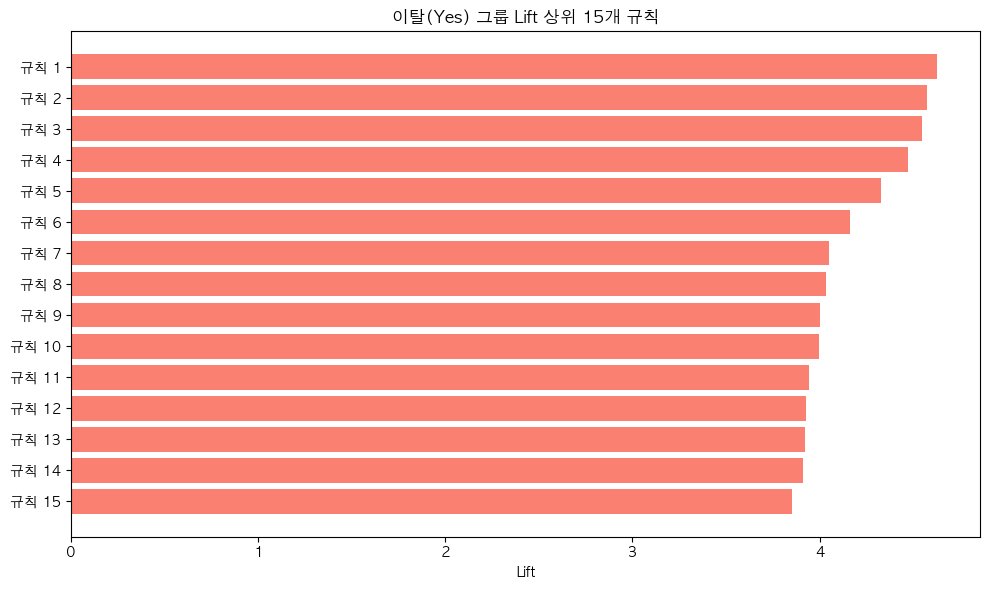

lift=4.626
  - InternetService = Fiber optic
  - PaymentMethod = Electronic check
  - TotalCharges_cut = (18.799, 402.225]

lift=4.576
  - StreamingMovies = Yes
  - Contract = Month-to-month
  - tenure_cut = (-0.001, 9.0]

lift=4.546
  - MultipleLines = Yes
  - InternetService = Fiber optic
  - tenure_cut = (-0.001, 9.0]

lift=4.470
  - StreamingTV = Yes
  - Contract = Month-to-month
  - tenure_cut = (-0.001, 9.0]

lift=4.329
  - SeniorCitizen = Yes
  - StreamingMovies = Yes
  - Contract = Month-to-month

lift=4.165
  - DeviceProtection = No
  - Contract = Month-to-month
  - MonthlyCharges_cut = (89.55, 118.75]

lift=4.052
  - PaperlessBilling = Yes
  - MonthlyCharges_cut = (70.2, 89.55]
  - TotalCharges_cut = (18.799, 402.225]

lift=4.036
  - OnlineBackup = No
  - Contract = Month-to-month
  - MonthlyCharges_cut = (89.55, 118.75]

lift=4.004
  - MultipleLines = Yes
  - Contract = Month-to-month
  - tenure_cut = (-0.001, 9.0]

lift=3.998
  - InternetService = Fiber optic
  - OnlineBack

In [26]:
# 상위 규칙 시각화
import matplotlib.pyplot as plt

top15 = yes_rules.head(15).copy()
top15['rule_str'] = top15['rule'].apply(
    lambda r: '\n'.join([c.replace('=>', '=') for c in r])
)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top15)), top15['lift'], color='salmon')
plt.yticks(range(len(top15)), [f"규칙 {i+1}" for i in range(len(top15))])
plt.xlabel('Lift')
plt.title('이탈(Yes) 그룹 Lift 상위 15개 규칙')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 규칙 상세 출력
for i, row in top15.iterrows():
    print(f"lift={row['lift']:.3f}")
    for cond in row['rule']:
        print(f"  - {cond.replace('=>', ' = ')}")
    print()

**[과제]** 가장 중요한 규칙에 해당하는 고객들의 실제 이탈률을 비교해서 해당 규칙이 실제로 유의미한지 검증해 보세요.

In [30]:
# ── 최고 Lift 규칙 정의 ──
top_rule = yes_rules.iloc[0]
print("【 최고 Lift 규칙 】")
print(f"Lift: {top_rule['lift']:.4f}")
for cond in top_rule['rule']:
    print(f"  - {cond.replace('=>', ' = ')}")

# 규칙 해당 고객 마스크
tc_q1 = data['TotalCharges_cut'].cat.categories[0]
rule_mask = (
    (data['InternetService'] == 'Fiber optic') &
    (data['PaymentMethod'] == 'Electronic check') &
    (data['TotalCharges_cut'] == tc_q1)
)

【 최고 Lift 규칙 】
Lift: 4.6261
  - InternetService = Fiber optic
  - PaymentMethod = Electronic check
  - TotalCharges_cut = (18.799, 402.225]


In [31]:
# ── 1. 이탈률 비교 ──
n_rule = rule_mask.sum()
churn_rule = (data.loc[rule_mask, 'Churn'] == 'Yes').sum()
churn_non  = (data.loc[~rule_mask, 'Churn'] == 'Yes').sum()
n_non = (~rule_mask).sum()

print(f"{'구분':<18} {'고객수':>6} {'이탈률':>8}")
print(f"{'규칙 해당':<18} {n_rule:>6} {(churn_rule/n_rule*100):>7.1f}%")
print(f"{'규칙 비해당':<18} {n_non:>6} {(churn_non/n_non*100):>7.1f}%")
print(f"{'전체':<18} {len(data):>6} {(data['Churn']=='Yes').mean()*100:>7.1f}%")

print("\n규칙 해당 Churn 분포:")
print(data.loc[rule_mask, 'Churn'].value_counts())
print("\n규칙 비해당 Churn 분포:")
print(data.loc[~rule_mask, 'Churn'].value_counts())

구분                    고객수      이탈률
규칙 해당                 394    75.9%
규칙 비해당               6649    23.6%
전체                   7043    26.5%

규칙 해당 Churn 분포:
Churn
Yes    299
No      95
Name: count, dtype: int64

규칙 비해당 Churn 분포:
Churn
No     5079
Yes    1570
Name: count, dtype: int64


In [32]:
# ── 2. 카이제곱 검정 ──
from scipy.stats import chi2_contingency
import numpy as np

table = np.array([
    [churn_rule, n_rule - churn_rule],
    [churn_non,  n_non - churn_non]
])
chi2, p_val, dof, _ = chi2_contingency(table)
odds_ratio = (table[0,0] * table[1,1]) / (table[0,1] * table[1,0])

print(f"Chi-square: {chi2:.2f}, p-value: {p_val:.2e}")
print(f"Odds Ratio: {odds_ratio:.2f}")
print(f"결론: {'통계적으로 유의함 ✓' if p_val < 0.05 else '유의하지 않음 ✗'}")

Chi-square: 518.73, p-value: 8.01e-115
Odds Ratio: 10.18
결론: 통계적으로 유의함 ✓
